# Netflix Content Strategy - Exploratory Data Analysis

An analysis of 8,807 Netflix titles to understand the platform's content strategy across **content type, geography, release timing, genre, and format** - and what gaps it reveals.

**Tools:** Python · Pandas · Matplotlib · Seaborn

**Dataset:** Netflix Movies and TV Shows (Kaggle)

In [1]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")

In [2]:
df.shape

(8807, 12)

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
clean = df.copy()

In [7]:
clean["director"] = clean["director"].fillna("Unknown")
clean["cast"] = clean["cast"].fillna("Unknown")
clean["country"] = clean["country"].fillna("Unknown")

In [8]:
clean.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [9]:
clean["date_added"] = pd.to_datetime(
    clean["date_added"].str.strip(),
    format="%B %d, %Y",
    errors="coerce"
)

In [10]:
clean["year_added"] = clean["date_added"].dt.year

In [11]:
clean["year_added"].min(), clean["year_added"].max()

(2008.0, 2021.0)

In [12]:
bug = clean["rating"].str.contains("min", na=False)

clean.loc[bug, "duration"] = clean.loc[bug, "rating"]
clean.loc[bug, "rating"] = "Unknown"

In [13]:
clean["rating"] = clean["rating"].fillna("Unknown")

In [14]:
clean["duration_num"] = pd.to_numeric(
    clean["duration"].str.split(" ").str[0],
    errors="coerce"
)

In [15]:
clean.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
duration_num     0
dtype: int64

In [16]:
clean["listed_in"] = clean["listed_in"].str.strip()

In [17]:
clean.to_csv("netflix_clean.csv", index=False)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

sns.set_style("whitegrid")
ACCENT = "#3A0CA3"

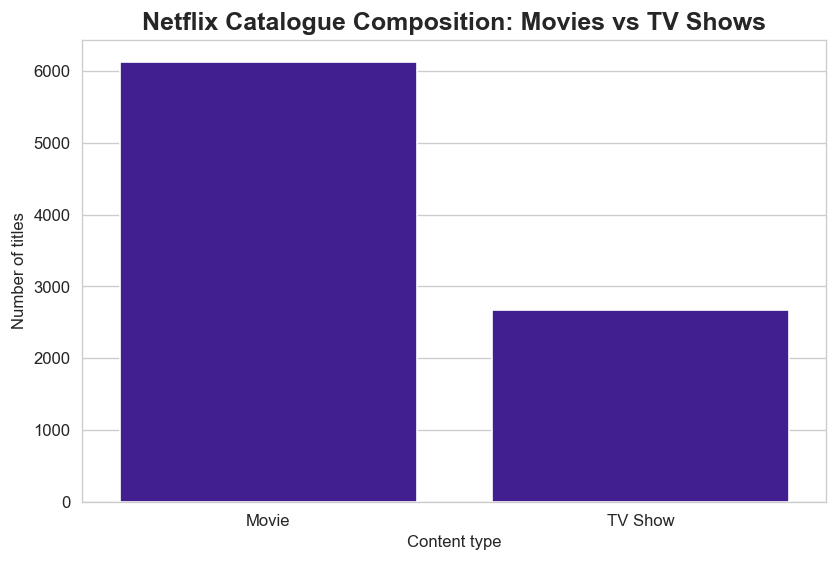

In [19]:
plt.figure(figsize=(8, 5))
type_counts = clean["type"].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, color=ACCENT)
plt.title("Netflix Catalogue Composition: Movies vs TV Shows")
plt.xlabel("Content type")
plt.ylabel("Number of titles")
plt.savefig("chart1_content_type.png", bbox_inches="tight")
plt.show()

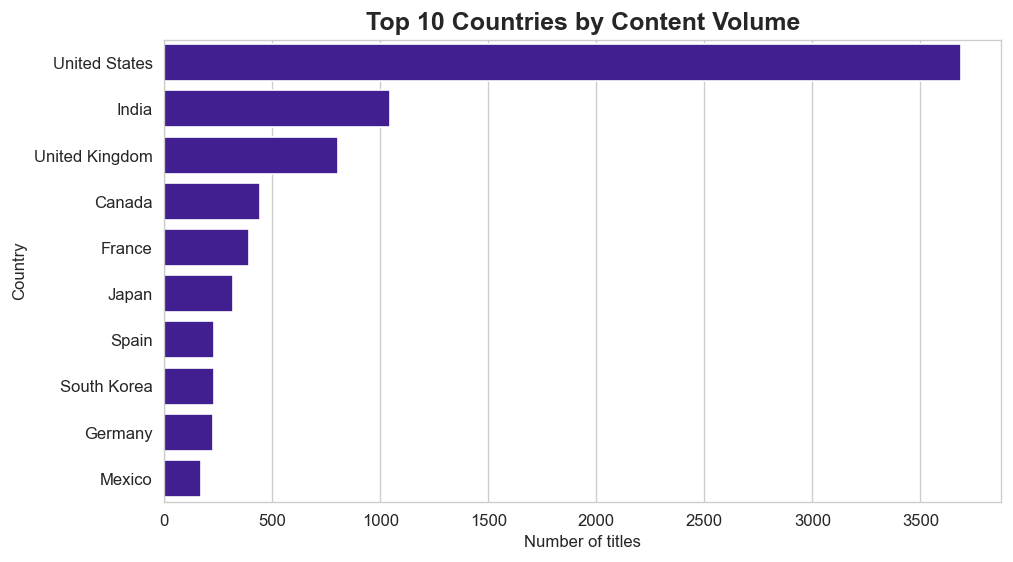

In [20]:
plt.figure(figsize=(9, 5))
countries = clean["country"].str.split(",").explode().str.strip()
countries = countries[countries != "Unknown"]
top_countries = countries.value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, color=ACCENT)
plt.title("Top 10 Countries by Content Volume")
plt.xlabel("Number of titles")
plt.ylabel("Country")
plt.savefig("chart2_top_countries.png", bbox_inches="tight")
plt.show()

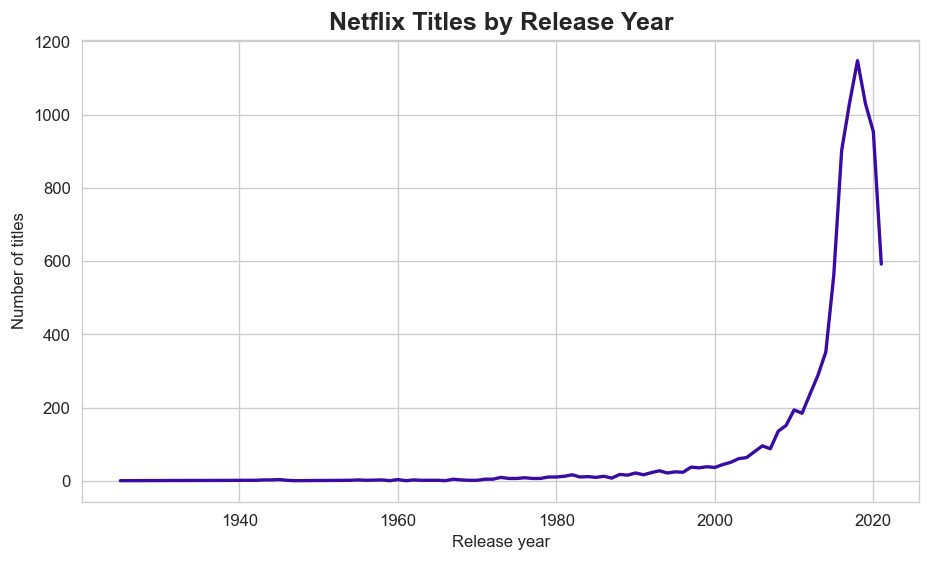

In [21]:
plt.figure(figsize=(9, 5))
releases = clean["release_year"].value_counts().sort_index()
releases.plot(kind="line", color=ACCENT, linewidth=2)
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release year")
plt.ylabel("Number of titles")
plt.savefig("chart3_releases_per_year.png", bbox_inches="tight")
plt.show()

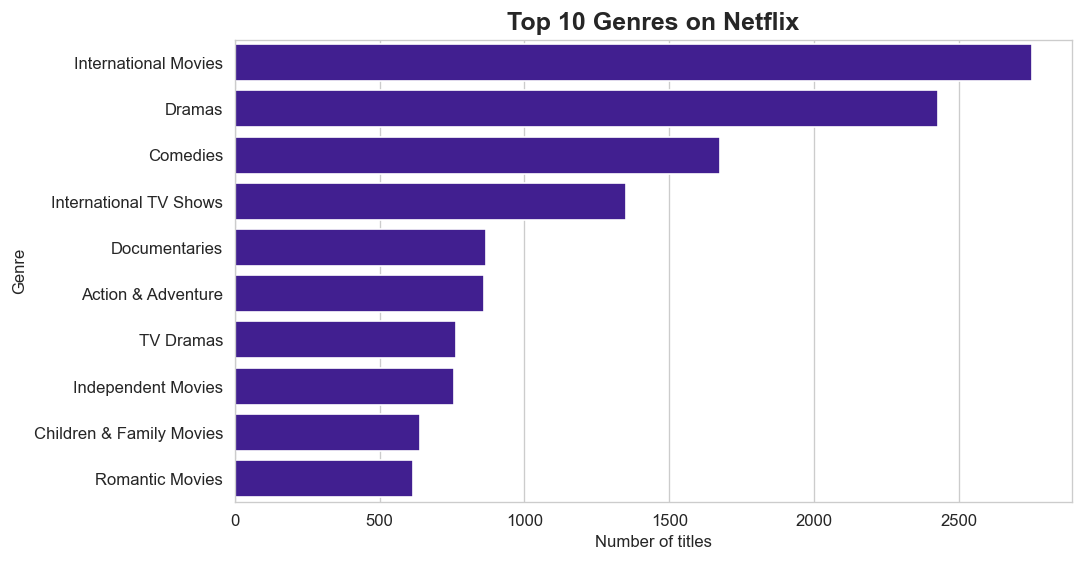

In [22]:
plt.figure(figsize=(9, 5))
genres = clean["listed_in"].str.split(",").explode().str.strip()
top_genres = genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, color=ACCENT)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of titles")
plt.ylabel("Genre")
plt.savefig("chart4_top_genres.png", bbox_inches="tight")
plt.show()

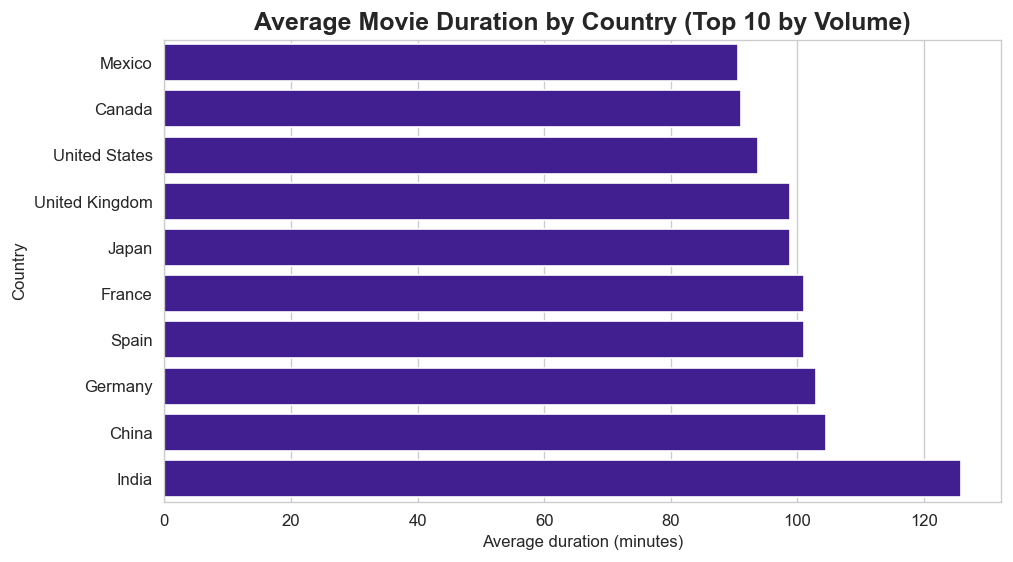

In [23]:
plt.figure(figsize=(9, 5))
movies = clean[clean["type"] == "Movie"].copy()
movies["country"] = movies["country"].str.split(",")
movies = movies.explode("country")
movies["country"] = movies["country"].str.strip()
movies = movies[movies["country"] != "Unknown"]
top10 = movies["country"].value_counts().head(10).index
avg_dur = (
    movies[movies["country"].isin(top10)]
    .groupby("country")["duration_num"]
    .mean()
    .sort_values()
)
sns.barplot(x=avg_dur.values, y=avg_dur.index, color=ACCENT)
plt.title("Average Movie Duration by Country (Top 10 by Volume)")
plt.xlabel("Average duration (minutes)")
plt.ylabel("Country")
plt.savefig("chart5_avg_duration.png", bbox_inches="tight")
plt.show()

## Key Findings

**1. Netflix is a movie-first platform.** Movies account for 6,131 titles (about 70%) versus 2,676 TV shows (about 30%).

**2. The catalogue is US-anchored with a global tail.** The United States leads with 3,690 titles — more than 3× the next country, India (1,046), followed by the UK (806) - while still drawing on dozens of countries worldwide.

**3. The library favours recent content.** Releases climbed sharply after 2015, peaked in 2018 (1,147 titles), then fell to 592 by 2021. Netflix's catalogue skews heavily toward the last decade.

**4. Drama, comedy and international content dominate.** The top genres are International Movies (2,752), Dramas (2,427) and Comedies (1,674). With "International" tags ranking #1 and #4, the catalogue reflects a strong global-content push.

**5. Indian films run notably longer.** Among the top-producing countries, Indian movies average about 126 minutes, compared with 90–105 minutes elsewhere — the Bollywood effect.